In [1]:
# bibliotecas
import pandas as pd                         # manipulação dos dados
import numpy as np                          # suporte de calculos
import matplotlib.pyplot as plt             # visualização grafica
import seaborn as sns                       # visualização grafica avançada
import plotly.express as px                 # visualização grafica Interativa
from matplotlib.ticker import FuncFormatter # auxiliar visualização do plt/sns
from scipy.stats import chi2_contingency    #Cramer_v - para vericar elação entre variaveis categoricas

In [2]:
# configurações
pd.set_option('display.float_format', lambda x: f'{x:,.2f}') # demonstra numeros no pandas em float
formatter = FuncFormatter(lambda x, _: f'{int(x):,}') # Formatter que converte o número para inteiro legível

## Carregamento dos Dados

Carregamos separado porque o dataset já vem dividido temporalmente.
Train = 2019, Test = 2020. Juntar e re-separar aleatoriamente causaria
data leakage, ou seja, informação do futuro vazando para o treino.

In [3]:
#df_train = pd.read_csv('fraudTrain.csv', index_col=0)
#df_test = pd.read_csv('fraudTest.csv', index_col=0)

In [4]:
# Carrega dados
df_train = pd.read_csv('../data/raw/fraudTrain.csv', index_col=0) # dados de 2019
df_test = pd.read_csv('../data/raw/fraudTest.csv', index_col=0)   # dados de 2020
# linhas x colunas
print(f'df_train: {df_train.shape}')
print(f'df_test: {df_test.shape}')

df_train: (1296675, 22)
df_test: (555719, 22)


## Reconhecimento

Realizando reconhecimento do dados se precisam modelar ou precisam de limpeza primeiro

In [5]:
# visualização df_train
display(df_train.head())

,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,Moravian Falls,...,36.08,-81.18,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.01,-82.05,0
1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,...,48.89,-118.21,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.16,-118.19,0
2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,Malad City,...,42.18,-112.26,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.15,-112.15,0
3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,Boulder,...,46.23,-112.11,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.03,-112.56,0
4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,Doe Hill,...,38.42,-79.46,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.67,-78.63,0


In [6]:
# confirmar compatibilidade de schema
print(df_train.dtypes.equals(df_test.dtypes))
print(f'Colunas train: {df_train.columns.tolist()}')
print(f'Colunas test:  {df_test.columns.tolist()}')

True
Colunas train: ['trans_date_trans_time', 'cc_num', 'merchant', 'category', 'amt', 'first', 'last', 'gender', 'street', 'city', 'state', 'zip', 'lat', 'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time', 'merch_lat', 'merch_long', 'is_fraud']
Colunas test:  ['trans_date_trans_time', 'cc_num', 'merchant', 'category', 'amt', 'first', 'last', 'gender', 'street', 'city', 'state', 'zip', 'lat', 'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time', 'merch_lat', 'merch_long', 'is_fraud']


Com a visuluzação resolvi olhar a fundo aque se refere cada dimensão um das dimensões do dataset
- trans_date_trans_time = data e hora da transacao
- cc_num = numero do cartao (anonimizado) - identificador
- merchant = nome do comerciante
- category = categoria do comerciante (gas_transport, shopping, etc.)
- amt = valor da transacao em dolares
- first = primeiro nome do titular - identificador
- last = sobrenome do titular - identidicador
- gender = genero (M/F)
- street = endereco do titular - identificador, alta cardanalidade
- city = cidade do titular
- state = estado do titular
- zip = CEP do titular - identificador
- lat = latitude do titular
- long = longitude do titular
- city_pop = populacao da cidade
- job = profissao do titular
- dob = data de nascimento
- trans_num = ID unico da transacao - identificador
- unix_time = timestamp unix
- merch_lat = latitude do comerciante
- merch_long = longitude do comerciante
- is_fraud = target — 0 legítima, 1 fraude

In [7]:
# visao geral consolidada conjunto de treino
df_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1296675 entries, 0 to 1296674
Data columns (total 22 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   trans_date_trans_time  1296675 non-null  object 
 1   cc_num                 1296675 non-null  int64  
 2   merchant               1296675 non-null  object 
 3   category               1296675 non-null  object 
 4   amt                    1296675 non-null  float64
 5   first                  1296675 non-null  object 
 6   last                   1296675 non-null  object 
 7   gender                 1296675 non-null  object 
 8   street                 1296675 non-null  object 
 9   city                   1296675 non-null  object 
 10  state                  1296675 non-null  object 
 11  zip                    1296675 non-null  int64  
 12  lat                    1296675 non-null  float64
 13  long                   1296675 non-null  float64
 14  city_pop               

In [8]:
# contagem de nulos no conjunto de treino
df_train.isnull().sum()

trans_date_trans_time    0
cc_num                   0
merchant                 0
category                 0
amt                      0
first                    0
last                     0
gender                   0
street                   0
city                     0
state                    0
zip                      0
lat                      0
long                     0
city_pop                 0
job                      0
dob                      0
trans_num                0
unix_time                0
merch_lat                0
merch_long               0
is_fraud                 0
dtype: int64

In [9]:
# contagem de duplicados
print(df_train.duplicated().sum())
print(df_test.duplicated().sum())

0
0


In [10]:
# Valores únicos por coluna — identifica colunas de ID e categóricas
df_train.nunique()

trans_date_trans_time    1274791
cc_num                       983
merchant                     693
category                      14
amt                        52928
first                        352
last                         481
gender                         2
street                       983
city                         894
state                         51
zip                          970
lat                          968
long                         969
city_pop                     879
job                          494
dob                          968
trans_num                1296675
unix_time                1274823
merch_lat                1247805
merch_long               1275745
is_fraud                       2
dtype: int64

In [11]:
# visualiza data, minima e maxima do df_train
trans_time_train = pd.to_datetime(df_train['trans_date_trans_time'])
print(f'Data minima: {trans_time_train.min()}')
print(f'Data maxima: {trans_time_train.max()}')
# visualiza data, minima e maxima do df_train
trans_time_test = pd.to_datetime(df_test['trans_date_trans_time'])
print(f'Data minima: {trans_time_test.min()}')
print(f'Data maxima: {trans_time_test.max()}')

Data minima: 2019-01-01 00:00:18
Data maxima: 2020-06-21 12:13:37
Data minima: 2020-06-21 12:14:25
Data maxima: 2020-12-31 23:59:34


## Periodo do Dataset

Train: 01/01/2019 a 21/06/2020  (18 meses)
Test:  21/06/2020 a 31/12/2020  (6 meses)
Divisao: continua, sem gap entre train e test.

## Distribuição  
com o reconhecimento dos dados realizados visto que não temos dados nulos e nem duplicados, e visualizado o que e cada variável representa, seguirei com a análise do comportamento das variaveis individualmente.
Tem algo estranho que pode enganar o modelo?

In [12]:
# visuliza colunas númericas relevantes
colunas_numericas = ['amt','lat', 'long', 'city_pop', 'merch_lat', 'merch_long', 'unix_time'] # zip e cc_num são identificadores, não métricas, excluí da análise
# analise das colunas numericas
df_train[colunas_numericas].describe().T

,count,mean,std,min,25%,50%,75%,max
amt,"1,296,675.00",70.35,160.32,1.00,9.65,47.52,83.14,"28,948.90"
lat,"1,296,675.00",38.54,5.08,20.03,34.62,39.35,41.94,66.69
long,"1,296,675.00",-90.23,13.76,-165.67,-96.80,-87.48,-80.16,-67.95
city_pop,"1,296,675.00","88,824.44","301,956.36",23.00,743.00,"2,456.00","20,328.00","2,906,700.00"
merch_lat,"1,296,675.00",38.54,5.11,19.03,34.73,39.37,41.96,67.51
merch_long,"1,296,675.00",-90.23,13.77,-166.67,-96.90,-87.44,-80.24,-66.95
unix_time,"1,296,675.00","1,349,243,636.73","12,841,278.42","1,325,376,018.00","1,338,750,742.50","1,349,249,747.00","1,359,385,375.50","1,371,816,817.00"


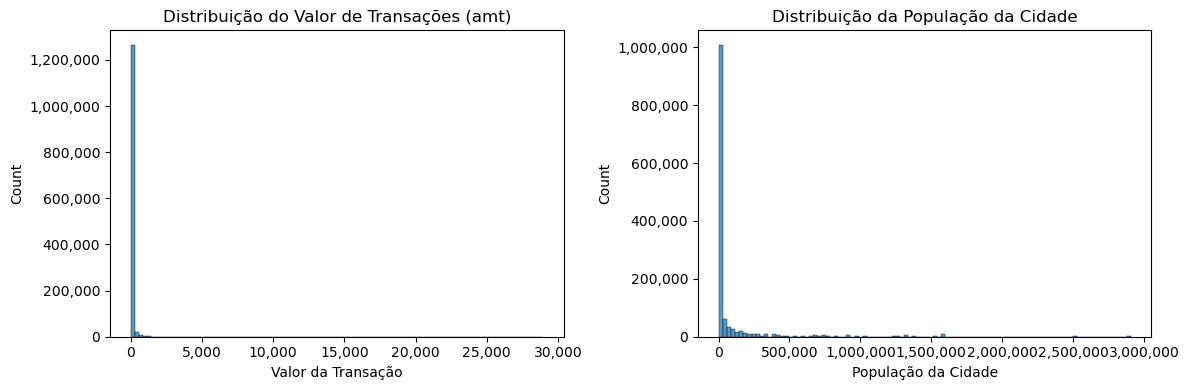

In [13]:
# visualizar amt e city_pop que possuem médias, medianas, e desvio padrão e valor máximo muitos discrepantes
fig, ax = plt.subplots(1,2, figsize=(12,4))

# visualização da distribuição do Valor de Transações (amt)
sns.histplot(df_train['amt'], bins=100, ax=ax[0])
ax[0].set_title('Distribuição do Valor de Transações (amt)')
ax[0].set_xlabel('Valor da Transação')
ax[0].xaxis.set_major_formatter(formatter)
ax[0].yaxis.set_major_formatter(formatter)

# visualização da distribuição da População da Cidade
sns.histplot(df_train['city_pop'], bins=100, ax=ax[1])
ax[1].set_title('Distribuição da População da Cidade')
ax[1].set_xlabel('População da Cidade')
ax[1].xaxis.set_major_formatter(formatter)
ax[1].yaxis.set_major_formatter(formatter)

plt.tight_layout()
plt.show()

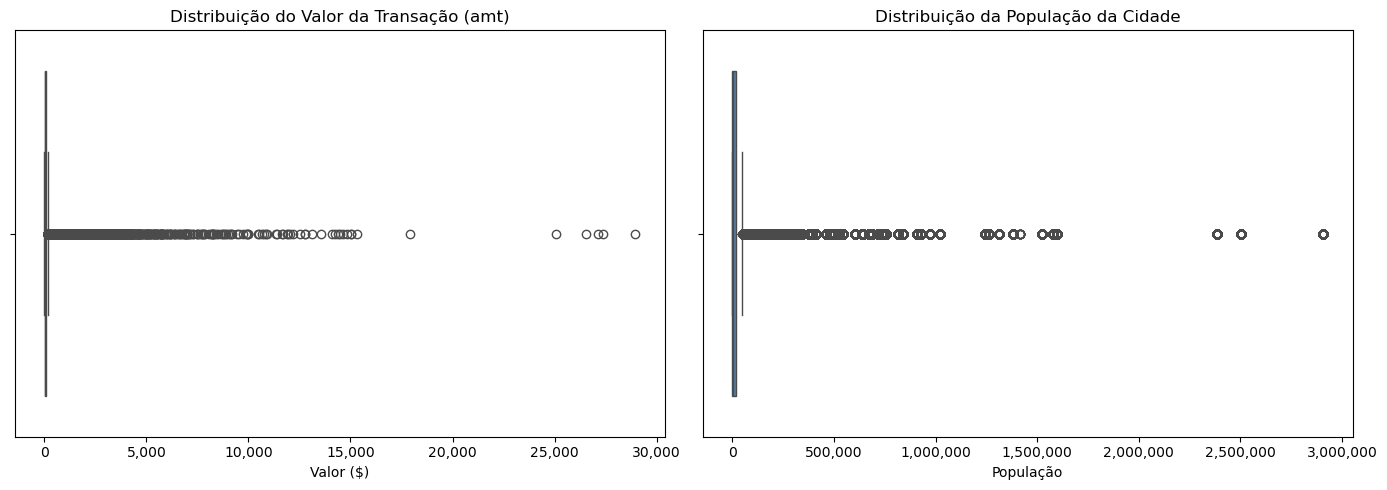

In [14]:
# Caudas muitos longas agrupadas nas partes mais baixas, o que faz parecer outliers, irei utilizar o boxplot para verificar melhor

# visualizar amt e city_pop em boxplot para melhor visualização dos outliers
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# visualizar boxplot do amt
sns.boxplot(x=df_train['amt'], ax=axes[0], color='steelblue')
axes[0].set_title('Distribuição do Valor da Transação (amt)')
axes[0].set_xlabel('Valor ($)')
axes[0].xaxis.set_major_formatter(formatter)

# visualizar boxplot do city_pop
sns.boxplot(x=df_train['city_pop'], ax=axes[1], color='steelblue')
axes[1].set_title('Distribuição da População da Cidade')
axes[1].set_xlabel('População')
axes[1].xaxis.set_major_formatter(formatter)

plt.tight_layout()
plt.show()

In [15]:
#Skew e Kurt das colunas numericas para atestar assimetria
status_assimetria = pd.DataFrame({
    'skew': df_train[colunas_numericas].skew(),
    'kurt': df_train[colunas_numericas].kurt()
})

print(status_assimetria)

            skew     kurt
amt        42.28 4,545.64
lat        -0.19     0.81
long       -1.15     1.86
city_pop    5.59    37.61
merch_lat  -0.18     0.80
merch_long -1.15     1.85
unix_time   0.00    -1.09


## Conclusão — Distribuição Numérica

é possivel perceber uma cauda muito longa nas duas variaveis analisadas, pois temos em amt a maioria das transações centralizadas abaixo de mil doláres e as transações maiores ficam quase invisiveis, e a maioria dos clientes se concentram em cidades pequenas tornando a visualização das cidade grandes praticamente impossivel, dificultando muito a visualização real dos dados.

`amt` e `city_pop` apresentam assimetria severa à direita com outliers
plausíveis (não são erros de coleta). Decisão: aplicar log1p no
preprocessing antes de modelar. Não remover outliers.

### Assimetria e Curtose

| Coluna    | Skew  | Kurt     | Decisão                        |
|-----------|-------|----------|--------------------------------|
| amt       | 31.36 | 2147.39  | log1p obrigatório              |
| city_pop  | 5.57  | 37.27    | log1p obrigatório              |
| lat       | -0.17 | 0.85     | sem transformação              |
| long      | -1.15 | 1.85     | vira feature de distância      |
| merch_lat | -0.17 | 0.83     | sem transformação              |
| merch_long| -1.15 | 1.84     | vira feature de distância      |
| unix_time | -0.17 | -1.12    | descartar após extrair hora/dia|.

In [16]:
#verificar distribuição da variavel target (is_fraud)
print(df_train['is_fraud'].value_counts())
print(df_train['is_fraud'].value_counts(normalize=True) * 100)

is_fraud
0    1289169
1       7506
Name: count, dtype: int64
is_fraud
0   99.42
1    0.58
Name: proportion, dtype: float64


## Distribuição do Target

| Classe | Absoluto | Percentual |
|--------|----------|------------|
| 0 (legítima) | 1.289.169 | 99.30% |
| 1 (fraude)   | 7.506     | 0.70%  |

Desbalanceamento severo, classe minoritária abaixo de 1%.
Estratégia: SMOTE no treino + class_weight='balanced' nos modelos.
Métricas: AUC-ROC, Precision-Recall e F1 pois são imunes ao fato do modelo "chutar" apenas e ter alto desempenho, e descartar Acurácia, como metrica de avaliação.

In [17]:
# Analise descritiva das categoricas relevantes
categoricas = {
    'gender': df_train['gender'],
    'state': df_train['state'],
    'job': df_train['job'],
    'merchant': df_train['merchant'],
    'category': df_train['category']
}

for coluna, serie in categoricas.items():
    print(f'{"="*50}')
    print(f'Coluna: {coluna.upper()}')
    print(f'Valores unicos: {serie.nunique()}')
    print(serie.value_counts(normalize=True).head(10) * 100)

Coluna: GENDER
Valores unicos: 2
gender
F   54.74
M   45.26
Name: proportion, dtype: float64
Coluna: STATE
Valores unicos: 51
state
TX   7.32
NY   6.44
PA   6.16
CA   4.35
OH   3.58
MI   3.56
IL   3.34
FL   3.29
AL   3.16
MO   2.96
Name: proportion, dtype: float64
Coluna: JOB
Valores unicos: 494
job
Film/video editor            0.75
Exhibition designer          0.71
Naval architect              0.67
Surveyor, land/geomatics     0.67
Materials engineer           0.64
Designer, ceramics/pottery   0.63
Systems developer            0.59
IT trainer                   0.59
Financial adviser            0.59
Environmental consultant     0.58
Name: proportion, dtype: float64
Coluna: MERCHANT
Valores unicos: 693
merchant
fraud_Kilback LLC                  0.34
fraud_Cormier LLC                  0.28
fraud_Schumm PLC                   0.28
fraud_Kuhn LLC                     0.27
fraud_Boyer PLC                    0.27
fraud_Dickinson Ltd                0.26
fraud_Cummerata-Jones              0.21


## Análise das Categóricas

| Coluna   | Únicos | Situação         | Decisão notebook 02         |
|----------|--------|------------------|-----------------------------|
| gender   | 2      | saudável, distribuição equilibrada        | encoding binário F=0, M=1   |
| state    | 51     | saudável, nenhum predominante       | One-Hot encoding            |
| category | 14     | saudável, distruição equilibrada , sem raridades        | One-Hot encoding            |
| job      | 481    | alta cardinalidade | agrupar por setor/renda   |
| merchant | 693    | alta cardinalidade + prefixo fraud_ | descartar ou remover prefixo|

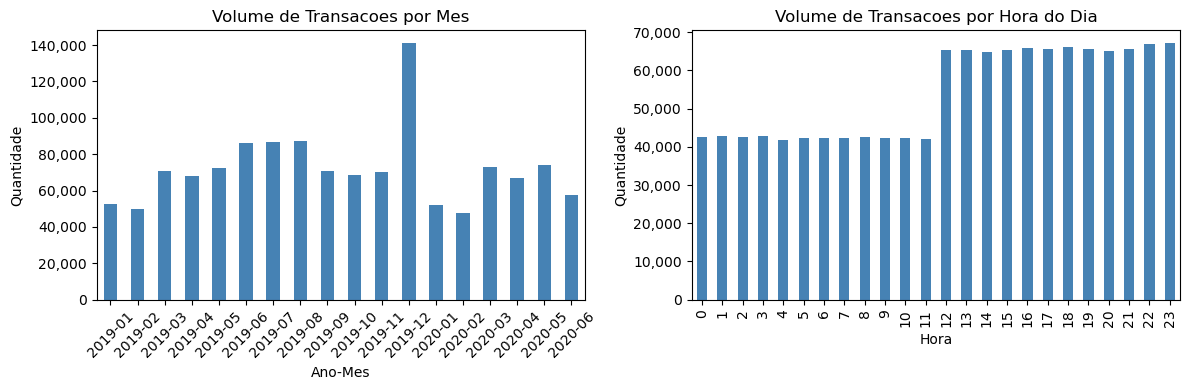

In [18]:
# Converte so para visualizacao — nao salva no df_train
trans_time_train = pd.to_datetime(df_train['trans_date_trans_time'])
volume_mensal = trans_time_train.dt.to_period('M').value_counts().sort_index()
volume_hora = trans_time_train.dt.hour.value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Volume por mes
volume_mensal.plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Volume de Transacoes por Mes')
axes[0].set_xlabel('Ano-Mes')
axes[0].set_ylabel('Quantidade')
axes[0].yaxis.set_major_formatter(formatter)
axes[0].tick_params(axis='x', rotation=45)

# Volume por hora
volume_hora.plot(kind='bar', ax=axes[1], color='steelblue')
axes[1].set_title('Volume de Transacoes por Hora do Dia')
axes[1].set_xlabel('Hora')
axes[1].set_ylabel('Quantidade')
axes[1].yaxis.set_major_formatter(formatter)

plt.tight_layout()
plt.show()

## Sazonalidade

- há uma sazonalidade, crescente para o fim do ano, porem no mes 11 subiu muito, talvez por anteceder epocas festivas e mes de promoções nos estados unidos onde é a base, talvez um alto volume de transações inplica tambem facilidade de fraudes passarem despercebidas
- por hora, o volume de transaçõe cai, mas nao zera, de 0 a 11 e volta subir de 12 a 23, apesar de se manter estavel dentro dos dois periodos, pelo fato de nao ser zero mais diminuir comprar na madrugada para alguns perfis podem indicar fraudes

## Analise com o target

irei verificar se as variaveis tem poder preditivo real, ou somente geram ruído

## Category

Taxa de fraude por category,  esperado: shopping_net e misc_net mais altas

In [19]:
# taxa de fraude por category
fraude_category = df_train.groupby('category')['is_fraud'].mean().mul(100).round(2).sort_values(ascending=False).reset_index()
display(fraude_category)

,category,is_fraud
0,shopping_net,1.76
1,misc_net,1.45
2,grocery_pos,1.41
3,shopping_pos,0.72
4,gas_transport,0.47
5,misc_pos,0.31
6,travel,0.29
7,grocery_net,0.29
8,entertainment,0.25
9,personal_care,0.24


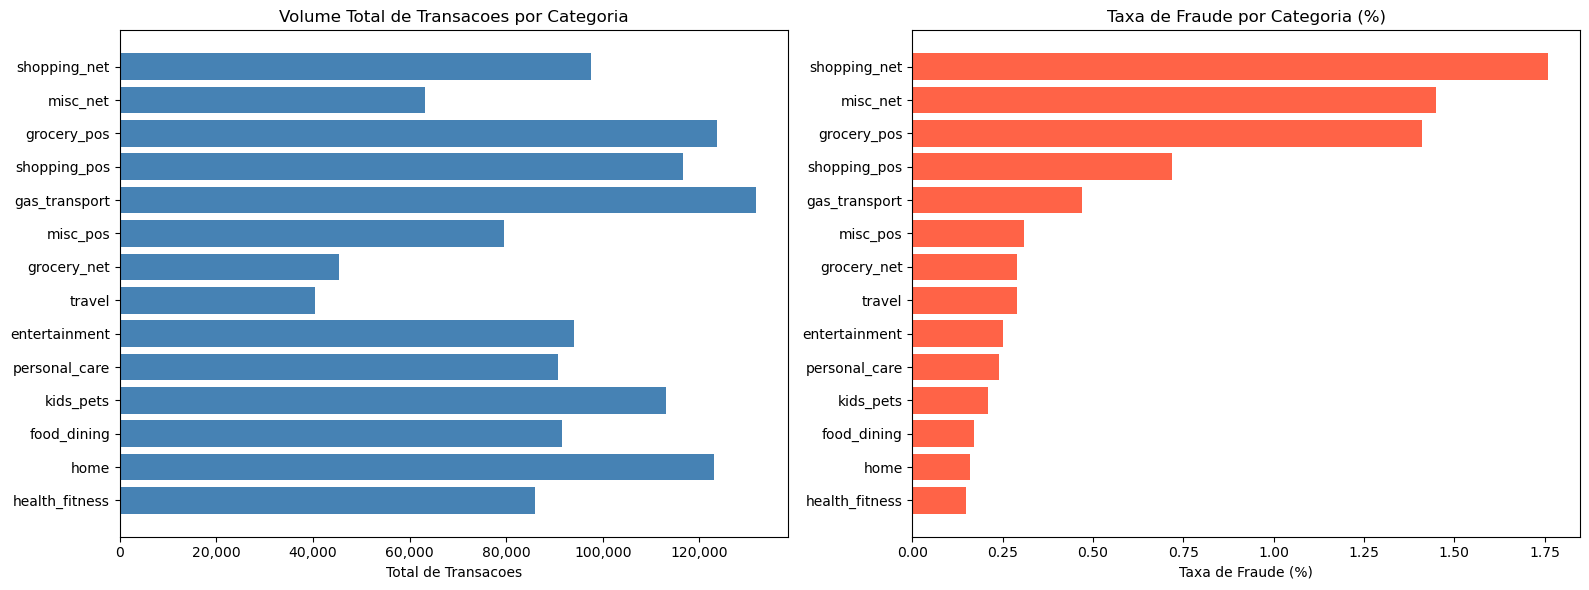

In [20]:
# calcula com agg para ter total e taxa juntos
fraude_categoria = df_train.groupby('category')['is_fraud'].agg(
    total='count',
    fraudes='sum'
).reset_index()

fraude_categoria['taxa_fraude_%'] = (
    fraude_categoria['fraudes'] / fraude_categoria['total'] * 100
).round(2)
# ordena pelo criterio principal — taxa de fraude
fraude_categoria_sorted = fraude_categoria.sort_values('taxa_fraude_%', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Grafico 1 — Volume total
axes[0].barh(fraude_categoria_sorted['category'],
             fraude_categoria_sorted['total'],
             color='steelblue')
axes[0].set_title('Volume Total de Transacoes por Categoria')
axes[0].set_xlabel('Total de Transacoes')
axes[0].xaxis.set_major_formatter(formatter)

# Grafico 2 — Taxa de fraude
axes[1].barh(fraude_categoria_sorted['category'],
             fraude_categoria_sorted['taxa_fraude_%'],
             color='tomato')
axes[1].set_title('Taxa de Fraude por Categoria (%)')
axes[1].set_xlabel('Taxa de Fraude (%)')

plt.tight_layout()
plt.show()

## Conclusão

hipotese parcialmete confirmada de que compras online tem maior possibilidade de fraude, mas nao é unico motivo, já que grocery_pos é a segunda mais alta, assim category é uma feature com alto poder preditivo

## AMT

Distribuicao de amt entre fraude e nao fraude, esperado: fraudes tem valor mais alto

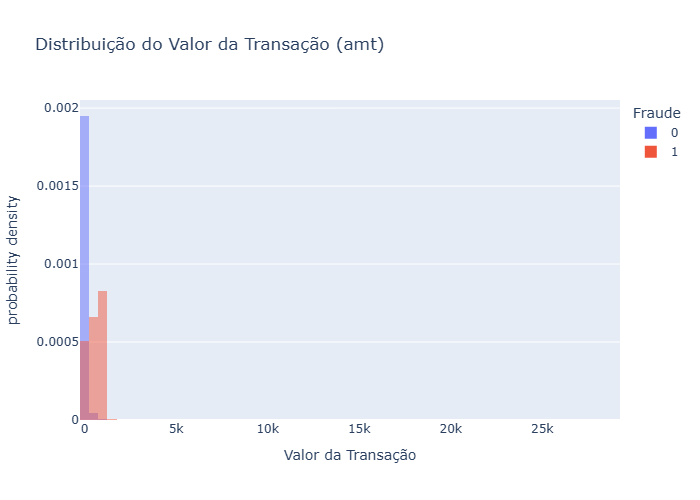

In [21]:
# visualiza a distribuição do 'amt' com seperação pela variavel target
fig = px.histogram(df_train,
                   x= 'amt',
                   histnorm= 'probability density',
                   nbins= 100,
                   title='Distribuição do Valor da Transação (amt)',
                   color='is_fraud',
                   barmode='overlay',
                   labels={'amt': 'Valor da Transação', 'is_fraud': 'Fraude'},
                   )

fig.show(renderer='png')

Como a variação é muito alta fica dificil de tirar conclusões, irei fazerum boxplot limitando o eixo vertical, olhando a distruição das classes ignorando os outliers mais extremos

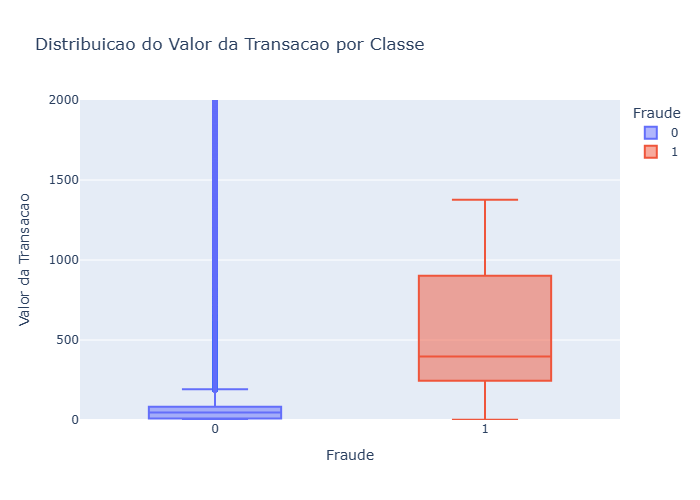

In [22]:
# visualiza o boxplot do 'amt' com o limite do eixo vertical
fig = px.box(df_train,
             x='is_fraud',
             y='amt',
             color='is_fraud',
             labels={'amt': 'Valor da Transacao', 'is_fraud': 'Fraude'},
             title='Distribuicao do Valor da Transacao por Classe',
             points= 'outliers')

# limita o eixo Y para focar na distribuicao principal
fig.update_yaxes(range=[0, 2000])

fig.show(renderer='png')

## Conclusao — amt x is_fraud

Hipotese confirmada. Mediana de fraude (500) e 5x maior que
mediana de transacao legitima (100). amt tem poder preditivo
alto e entra no modelo como feature prioritaria.

## Trans_date_trans_time x is_fraud

Horas têm volume baixo mais nao nulo no periodo de 0 a 11, hipotese: esse volume de madrugada vai ter taxa de fraude maior proporcionalmente

In [23]:
# cria um dataframe com hora e is_fraud
df_hora = pd.DataFrame({
    'Hora':trans_time_train.dt.hour,
    'is_fraud':df_train['is_fraud']
})

# calculo da taxa de fraude por hora

fraude_hora = df_hora.groupby('Hora')['is_fraud'].agg(
    total='count',
    fraudes='sum'
).reset_index()

fraude_hora['taxa_fraude_%'] = (fraude_hora['fraudes'] / fraude_hora['total'] * 100).round(2)

display(fraude_hora)

,Hora,total,fraudes,taxa_fraude_%
0,0,42502,635,1.49
1,1,42869,658,1.53
2,2,42656,625,1.47
3,3,42769,609,1.42
4,4,41863,46,0.11
5,5,42171,60,0.14
6,6,42300,40,0.09
7,7,42203,56,0.13
8,8,42505,49,0.12
9,9,42185,47,0.11


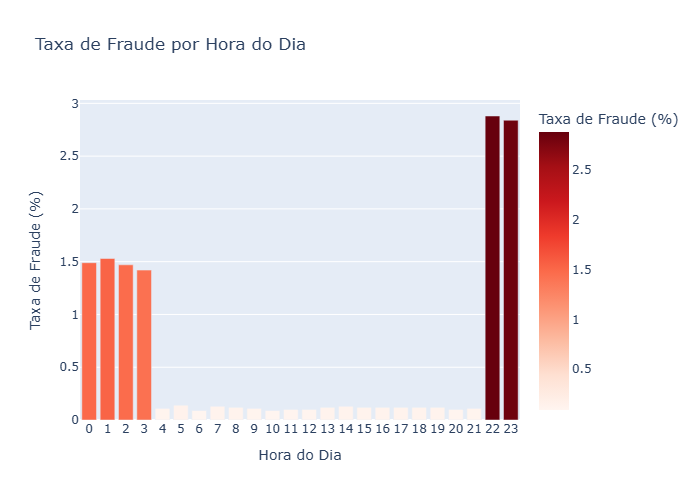

In [24]:
# visualiza taxa de fraude

fig = px.bar(fraude_hora,
             x='Hora',
             y='taxa_fraude_%',
             color='taxa_fraude_%',
             title='Taxa de Fraude por Hora do Dia',
             color_continuous_scale='Reds',
             labels={'Hora': 'Hora do Dia', 'taxa_fraude_%': 'Taxa de Fraude (%)'})

fig.update_xaxes(dtick=1)
fig.show(renderer='png')

## Conclusao — Hora x is_fraud

Hipotese parcialmente confirmada e enriquecida.

Dois blocos de alto risco identificados:
- 22h e 23h: taxa de 3.45% e 3.76% — pico mais alto do dia
- 00h a 03h: taxa entre 1.78% e 2.27% — madrugada confirmada

Horario comercial (04h a 21h): taxa abaixo de 0.25% — periodo seguro.

Decisao notebook 02: criar feature binaria is_horario_risco
onde hora >= 22 ou hora <= 3 recebe valor 1.

## Gender

Taxa de fraude por gender,  hipotese: tem padrao de consumo diferente,mulheres constumam ter mais compras em shopping e misc do que homens, e estão mais sujeitas a cairem em fraudes

In [25]:
# cria agrupamento por gênero
fraude_gender = df_train.groupby('gender')['is_fraud'].agg(
    total='count',
    fraudes='sum'
).reset_index()
# calcula taxa de fraude
fraude_gender['taxa_fraude_%'] = (
    fraude_gender['fraudes'] / fraude_gender['total'] * 100
).round(2)

display(fraude_gender)

,gender,total,fraudes,taxa_fraude_%
0,F,709863,3735,0.53
1,M,586812,3771,0.64


## Conclusao — gender x is_fraud

Hipotese refutada. Homens tem taxa levemente maior (0.64%)
que mulheres (0.53%) — diferenca de 0.11pp.

Efeito pequeno. gender entra no modelo mas nao sera
preditor relevante. SHAP confirmara no notebook 04.

## State X Is_fraude

Taxa de fraude por state, State: estados tem padroes de consumo diferente. hipotese: estados com valores de transações maiores tem mais fraudes

In [26]:
# cria agrupamento por state e its_fraud
fraude_state = df_train.groupby('state')['is_fraud'].agg(
    total='count',
    fraudes='sum'
).reset_index()
# calcula taxa de fraude
fraude_state['taxa_fraude_%'] = (
    fraude_state['fraudes'] / fraude_state['total'] * 100
).round(2)
# ordena pelas mairoes taxas
fraude_state = fraude_state.sort_values('taxa_fraude_%', ascending=False)

display(fraude_state)

,state,total,fraudes,taxa_fraude_%
8,DE,9,9,100.00
39,RI,550,15,2.73
0,AK,2120,36,1.70
33,NV,5607,47,0.84
5,CO,13880,113,0.81
42,TN,17554,140,0.80
37,OR,18597,149,0.80
29,NE,24168,180,0.74
21,ME,16505,119,0.72
30,NH,8278,59,0.71


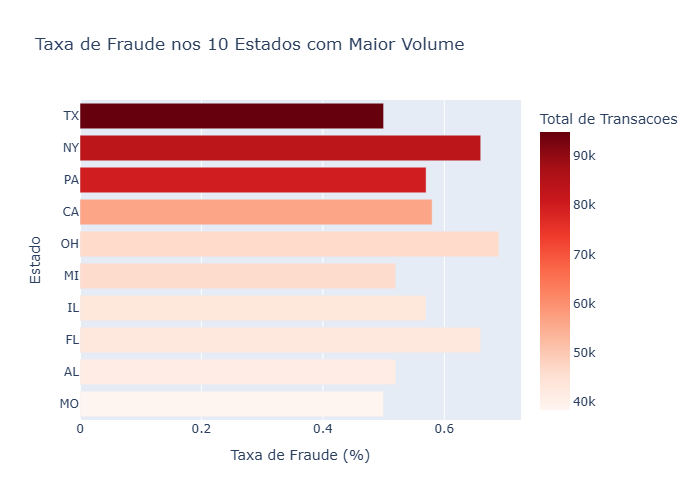

In [27]:
# visualiza maiores numeros de transações por taxa de fraude
top10_estados = fraude_state.nlargest(10, 'total').sort_values('taxa_fraude_%', ascending=True)

top10_estados = fraude_state.nlargest(10, 'total').sort_values('total', ascending=True)

fig = px.bar(top10_estados,
             x='taxa_fraude_%',
             y='state',
             color='total',
             orientation='h',
             title='Taxa de Fraude nos 10 Estados com Maior Volume',
             color_continuous_scale='Reds',
             labels={'state': 'Estado',
                     'taxa_fraude_%': 'Taxa de Fraude (%)',
                     'total': 'Total de Transacoes'})

fig.show(renderer='png')

## Conclusão State

Hipótese refutada: estado com maiores transações nao possuem maior taxa de fraude.

DE (9 transacoes, 100% fraude) e RI (550 transacoes, 2.73%)
sao categorias raras com taxa instavel — ruido estatistico.

Decisao notebook 02: agrupar DE e RI em 'outros' antes do encoding.

Demais estados: variacao entre 0.43% e 0.84% — diferenca moderada.
state tem poder preditivo baixo individualmente mas pode
contribuir em combinacao com outras features.

## mes x is_fraud
novembro tem um volume maior de compras, hipotese: volumes maiores de compra tem ruído mais alto que propicia maior numero de fraudes

In [28]:
# cria um dataframe com mes e is_fraud
df_mes = pd.DataFrame({
    'mes': trans_time_train.dt.to_period('M'),
    'is_fraud':df_train['is_fraud']
})

# calculo da taxa de fraude por mes

fraude_mes = df_mes.groupby('mes')['is_fraud'].agg(
    total='count',
    fraudes='sum'
).reset_index()

fraude_mes['taxa_fraude_%'] = (fraude_mes['fraudes'] / fraude_mes['total'] * 100).round(2)

display(fraude_mes)

,mes,total,fraudes,taxa_fraude_%
0,2019-01,52525,506,0.96
1,2019-02,49866,517,1.04
2,2019-03,70939,494,0.70
3,2019-04,68078,376,0.55
4,2019-05,72532,408,0.56
5,2019-06,86064,354,0.41
6,2019-07,86596,331,0.38
7,2019-08,87359,382,0.44
8,2019-09,70652,418,0.59
9,2019-10,68758,454,0.66


## Conclusao — mes x is_fraud

Hipotese refutada. Alto volume nao implica alta taxa de fraude.
Dezembro 2019 tem maior volume (141k) mas taxa de apenas 0.42%.

Padrao real: janeiro e fevereiro tem taxas mais altas (0.96% e 1.04%)
com volume moderado.

mes tem poder preditivo baixo. Feature temporal mais relevante
identificada na analise de hora (blocos 22h-23h e 00h-03h).

## Job x Is_fraud
 job: profissões com maiores salarios tem acesso a maior valor. hipotese: profissoes melhores tem transações de maior valor.


In [29]:
# cria agrupamento job e is_fraud
fraude_job = df_train.groupby('job')['is_fraud'].agg(
    total='count',
    fraudes='sum'
).reset_index()
# calculo da taxa de fraude
fraude_job['taxa_fraude_%'] = (
    fraude_job['fraudes'] / fraude_job['total'] * 100
).round(2)

fraude_job = fraude_job.sort_values('taxa_fraude_%', ascending=False)

display(fraude_job)

,job,total,fraudes,taxa_fraude_%
20,Air traffic controller,17,17,100.00
267,Legal secretary,12,12,100.00
51,Broadcast journalist,9,9,100.00
35,Armed forces technical officer,8,8,100.00
245,Information officer,8,8,100.00
...,...,...,...,...
454,Teaching laboratory technician,1506,0,0.00
33,Archivist,1519,0,0.00
38,Art therapist,2055,0,0.00
470,"Therapist, sports",2564,0,0.00


In [30]:
# filtra transações para melhor visualizacao
fraude_job_filtrado = fraude_job[fraude_job['total'] >= 1000]
print(f'Jobs com mais de 1000 transacoes: {len(fraude_job_filtrado)}')
print(fraude_job_filtrado.sort_values('taxa_fraude_%', ascending=False).head(10))

Jobs com mais de 1000 transacoes: 416
                                job  total  fraudes  taxa_fraude_%
293       Medical technical officer   1066       25           2.35
335            Pharmacist, hospital   1059       24           2.27
139                       Economist   1042       23           2.21
80                   Chief of Staff   1030       20           1.94
46             Biochemist, clinical   1038       19           1.83
309                Network engineer   1553       24           1.55
311               Nurse, children's   2589       40           1.54
347         Presenter, broadcasting   1039       16           1.54
127            Designer, multimedia   1053       16           1.52
283  Manufacturing systems engineer   1001       15           1.50


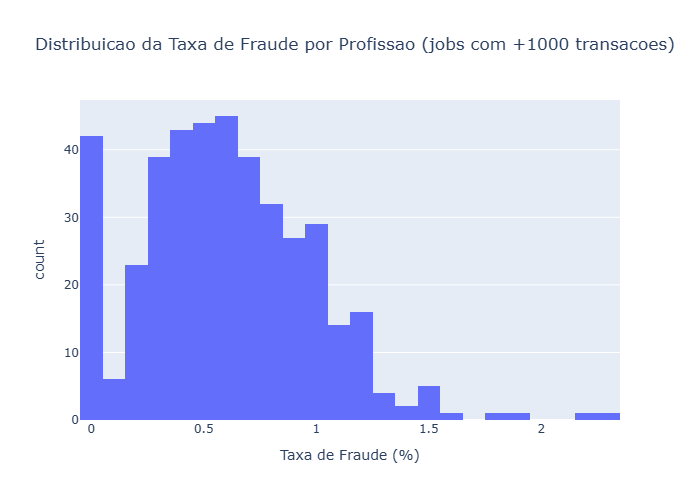

In [31]:
# histograma da distribuição
fig = px.histogram(fraude_job_filtrado,
                   x='taxa_fraude_%',
                   nbins=30,
                   title='Distribuicao da Taxa de Fraude por Profissao (jobs com +1000 transacoes)',
                   labels={'taxa_fraude_%': 'Taxa de Fraude (%)'})

fig.show(renderer='png')

## Conclusão job X is_fraud

Hipótese refutada. Profissão não tem poder preditivo direto sobre fraude. O que importa é o padrão de gasto — amt e category são muito mais relevantes que job.

## Analise multivariada

verificar o que é redundante ou se combina bem?

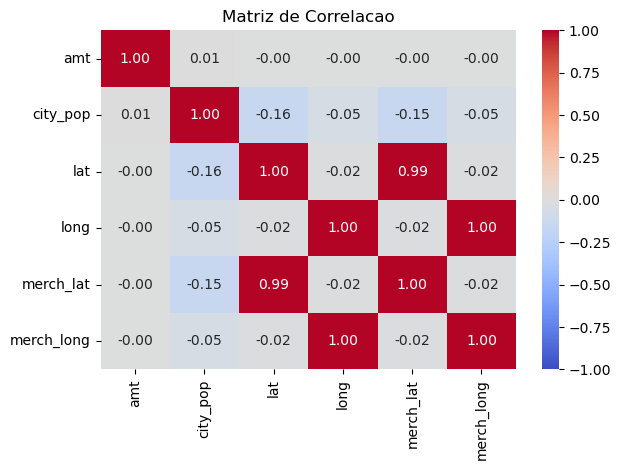

In [32]:
# analise de matriz de correlacao
colunas_numericas = ['amt', 'city_pop', 'lat', 'long', 'merch_lat', 'merch_long']

corr_matrix = df_train[colunas_numericas].corr()

sns.heatmap(corr_matrix,
            annot=True,
            cmap='coolwarm',
            fmt='.2f',
            center=0,
            vmin=-1,
            vmax=1
            )
plt.title('Matriz de Correlacao')
plt.tight_layout()
plt.show()

## correlações

como haviamos visto na analise inicial `merch_long` e `long`, `merch_lat` e `lat`, possuem alta correlação esperada pois cliente e comerciante tendem a estar proximos.Essas quatro colunas serao substituidas por uma unica feature
distancia_km no notebook 02 — calculada como distancia geografica entre cliente e comerciante.

Demais correlações ou são nulas, ou tem correlação negativa de baixa força, iremos analisar algumas hipoteses categoricas se conseguimos encontrar soma de formças entre elas em situações especificas


## amt x hora

 fatores de risco que se complementam ? hipotese valores altos  e horario da madrugada aumentam o risco

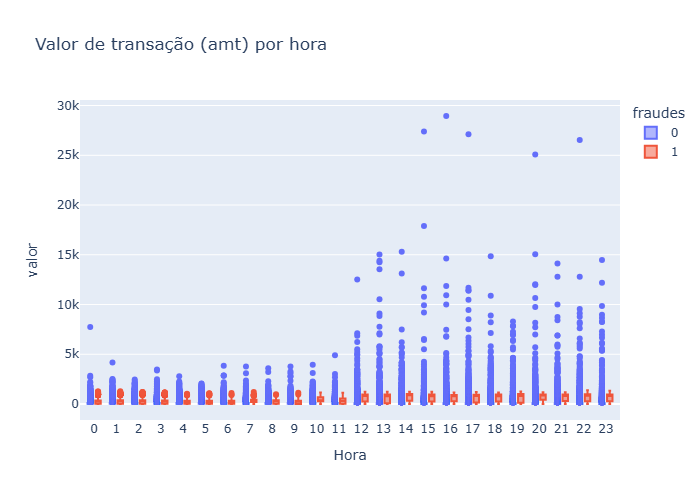

In [33]:
# dia dataframe de hora e amt

df_hora_amt = pd.DataFrame({
    'hora': trans_time_train.dt.hour,
    'valor': df_train['amt'],
    'fraudes': df_train['is_fraud']
})

# visualiza boxplot

Fig = px.box(df_hora_amt,
             x='hora',
             y='valor',
             title='Valor de transação (amt) por hora',
             color='fraudes',
             labels={'hora': 'Hora', 'amt': 'Valor ($)', 'is_fraud': 'Fraude'},
             )

Fig.update_xaxes(dtick=1)
Fig.show(renderer='png')

## conclusão — amt x hora

**Hipotese:** valores altos e horario de madrugada aumentam o risco combinados.

**Visualizacao 1 — Boxplot:**
- Caixa de fraude (vermelho) estavel em todas as 24 horas
- Mediana de fraude consistente em torno de 400-500 independente da hora
- Outliers de alto valor concentrados no periodo diurno sao transacoes legitimas
- amt e hora sao features independentes — nao se potencializam combinadas

**Hipotese refutada:** fraudes de madrugada nao tem valor maior que fraudes diurnas.
Nao e necessario criar feature de interacao entre amt e hora no notebook 02.

## category x amt
 categorias diferentes têm perfis de valor diferentes? hipoterse: shopping_net tem ticket médio maior por ter o maior percentual de fraudes


In [34]:
# criar dataframe de category e amt agrupados
category_amt = df_train.groupby('category')['amt'].agg(
    total='count',
    media='mean',
    mediana='median',
    amt='sum'
).round(2).reset_index()

# junta com a taxa de fraude ja calculada
category_amt = category_amt.merge(
    fraude_categoria[['category', 'taxa_fraude_%']],
    on='category')

category_amt = category_amt .sort_values('media', ascending=False)
display(category_amt)

,category,total,media,mediana,amt,taxa_fraude_%
4,grocery_pos,123638,116.96,105.12,"14,460,822.38",1.41
13,travel,40507,111.50,6.26,"4,516,721.68",0.29
11,shopping_net,97543,88.42,8.44,"8,625,149.68",1.76
8,misc_net,63287,80.87,9.84,"5,117,709.26",1.45
12,shopping_pos,116672,79.78,7.76,"9,307,993.61",0.72
0,entertainment,94014,64.21,50.74,"6,036,678.56",0.25
2,gas_transport,131659,63.43,62.84,"8,351,732.29",0.47
9,misc_pos,79655,62.89,13.92,"5,009,582.50",0.31
6,home,123115,58.27,48.29,"7,173,928.11",0.16
7,kids_pets,113035,57.54,47.18,"6,503,680.16",0.21


## Conclusao — category x amt

hipotese refutada.  hipotese refutada. Ticket medio alto nao implica
taxa de fraude alta. O canal online vs presencial nao e determinante
— grocery_pos (presencial) tem taxa maior que grocery_net (online),
quebrando o padrao. A categoria especifica e mais relevante que o canal.
category e amt contribuem de forma independente para o modelo.

In [35]:
def cramers_v(col1, col2):
    # tabela de contingencia, conta combinacoes entre as duas colunas
    tabela = pd.crosstab(col1, col2)

    # chi2 mede se existe associacao estatistica entre as duas variaveis
    chi2 = chi2_contingency(tabela)[0]

    # n = total de observacoes
    n = tabela.sum().sum()

    # k = menor numero de categorias entre as duas colunas
    k = min(tabela.shape) - 1

    return np.sqrt(chi2 / (n * k))

# calcula para os dois pares
print(f'gender x category: {cramers_v(df_train['gender'], df_train['category']):.3f}')
print(f'state x category:  {cramers_v(df_train['state'], df_train['category']):.3f}')
print(f'merchant x category: {cramers_v(df_train['merchant'], df_train['category']):.3f}')
print(f'job x category: {cramers_v(df_train['job'], df_train['category']):.3f}')
print(f'job x gender: {cramers_v(df_train['job'], df_train['gender']):.3f}')
print(f'state X gender:{cramers_v(df_train['state'], df_train['gender']):.3f}')
print(f'job x state: {cramers_v(df_train['job'], df_train['state']):.3f}')

gender x category: 0.054
state x category:  0.020
merchant x category: 0.995
job x category: 0.052
job x gender: 0.747
state X gender:0.256
job x state: 0.739


| Analises colunas categoricas| Cramer   |  analise                         |
|-----------------------------|----------|----------------------------------|
|merchant x category  |0.995  |    redundancia confirmada, descartar merchant|
|job x gender         |0.747  |    job captura sinal de gender|
|state x gender       |0.256  |    associacao fraca, nao e confundimento forte |
|job x state          |0.739  |    profissoes concentradas geograficamente|

- demais categorias abaix 0.1 negligenciaveis
- irei verificar merchant x category, para ver se é realmente redundate ou tem muitos operando em mais duas categorias

## merchant x category

possuem relação redunte ou temos muito estabelecimentos operando em mais de uma categoria ?

In [36]:
# dataframe para visualziar quantos merchants operam em mais de uma categoria?
merchant_categorias = df_train.groupby('merchant')['category'].nunique()
display(merchant_categorias.value_counts())

category
1    686
2      7
Name: count, dtype: int64

## Conclusao merchant X category
**Confirmacao:**
686 de 693 merchants (99%) operam em uma unica categoria.
7 merchants operam em duas categorias — menos de 1%.
merchant e completamente redundante com category.
Decisao definitiva: descartar merchant no notebook 02.

## Hipoteses Pendentes

### Camada 3 — Relacao com Target
- [x] Taxa de fraude por category,  esperado: shopping_net e misc_net mais altas
- [x] Taxa de fraude por gender,  hipotese: tem padrao de consumo diferente,mulheres constumam ter mais compras em shopping e misc do que homens, e estão mais sujeitas a cairem em fraudes. (
- [x] Taxa de fraude por state, State: estados tem padroes de consumo diferente. hipotese: estados com valores de transações maiores tem mais fraudes
- [x] Distribuicao de amt entre fraude e nao fraude, esperado: fraudes tem valor mais alto
- [x] Horas têm volume baixo mais nao nulo no periodo de 0 a 11, hipotese: esse volume de madrugada vai ter taxa de fraude maior proporcionalmente
- [x] novembro tem um volume maior de compras, hipotese: volumes maiores de compra tem ruído mais alto que propicia maior numero de fraudes
- [x] job: profissões com maiores salarios tem acesso a maior valor. hipotese: profissoes melhores tem transações de maior valor.

| Coluna   | Decisão notebook 02         |
|----------|-----------------------------|
|category  | confirmada, poder preditivo alto|
|amt       | confirmada, poder preditivo alto|  
|hora      | confirmada e enriquecida, dois blocos de risco|
|mes       | refutada, poder preditivo baixo|
|gender    | refutada, diferenca minima|
|state     | parcialmente confirmada, DE e RI sao ruido|
|job       | refutada, sem poder preditivo direto|


### Camada 4 — Multivariada
fatores de risco que se complementam ?
- [x] matriz de correlação, o que complementa o que?
- [x] category x amt,  categorias diferentes têm perfis de valor diferentes? hipoterse: shopping_net tem ticket médio maior por ter o maior percentual de fraudes
- [x] amt x hora, fatores de risco que se complementam ? hipotese valores altos  e horario da madrugada aumentam o risco
- [x] cramer V, há alguma correlação categorica?
- [x] merchant x category, tem relação redundante?
- [x] job é variavel confundira para gender x state?



# Sintese Conclusao Final - EDA

## O que o dado revelou

**Target:** desbalanceamento severo: 0.70% de fraude.
Estrategia: SMOTE + class_weight='balanced'. Metrica: AUC-ROC e F1.

**Features com alto poder preditivo:**
- category: variacao de 0.13% a 1.83% de taxa de fraude
- amt: mediana de fraude 5x maior que transacao legitima
- hora: dois blocos de risco: 22h-23h (3.5%+) e 00h-03h (2%+)

**Features com baixo poder preditivo:**
- gender, mes, state, job: variacao pequena ou inconsistente

### Decisoes Pendentes notebook 02

**Remover**
- [x] `CONFIRMADO`Descartar merchant (redundante com category) aos invés de  criar target com 481 opções, somente um one-hot enconder com 14 já mantem as informações
- [x] `CONFIRMADO` Descartar gender (capturado por job)
- [x] `CONFIRMADO` Remover unix_time
- [x] `confirmado` remover colunas identificadoras

**Encoding:**
- [x] `CONFIRMADO` job com Target Encoding (481 categorias)
- [x] `CONFIRMADO` state — One-Hot (51 categorias, agrupar DE e RI em outros)
- [x] `CONFIRMADO` category — One-Hot (14 categorias)
      


**Transformar**
- [x] amt — log1p
- [x] city_pop — log1p


**Criar features novas:**
- [x] `CONFIRMADO` Distancia_km, Calcular distancia entre cliente e merchant via lat/long
- [x] `CONFIRMADO`Extrair hora, dia da semana e mes do trans_date_trans_time
- [x] `CONFIRMADO` dob, calcular a idade do clientes

**Nao realizar**
- [ ] `DESCARTADO` is_horario_risco — hora >= 22 ou hora <= 3 - motivo que como numerica captura o sinal diretamente nao adiciona informação nova
- [ ] `DESCARTADO` is_onbline criar separação de categorias online - hipotese que compras online tem mais fraude foi refutada pelo dado que compras online
- [ ] `DESCARTADO` Remover prefixo fraud_ do merchant, iremos remover merchant como um todo, trabalhao redundante

## Hipotese do Projeto

O perfil comportamental do cliente capturado pelo cluster K-Means
no notebook 03 vai melhorar a deteccao de fraude porque o que e
suspeito para um perfil pode ser normal para outro.

O EDA confirma que existem padroes distintos de comportamento:
categorias preferidas, faixa de valor, horario de compra.
Esses padroes sao a base da segmentacao comportamental